# Introduction

This guide explains how to use the `decentralized market software` and in doing so explains the economics behind the software.  

## A Brief Overview
Here is a very brief description that will be explained in more detail later in this guide.

### Agent Types
* There are **num_traders** agents who are either a `BUYER` or a `SELLER`. In the baseline case, there is an equal number of buyers and sellers.
* Agent behavior is dictated by their strategic type.

> Presently, you can choose from the following agent types:
* `ZID`: Basic zero intelligence trader. Makes and accepts bids/asks randomly within its budget and moves randomly in every period. See Gode and Sunder 1993.
* `ZIDP`: Extend ZID - but accepts only the most favorable bid/ask available.
* `ZIDA`: Extend ZID - but uses a rule-of-thumb movement rule which lead to staying at locations if an agent traded recently. The default rule of thumb is for an agent to stay at a location if they have traded at least $num\_ trades$ times in the last $window\_ size$ periods, with $num \_ trades = 1$ and $window\_ size = num\_ periods$ (the length of one week).
* `ZIDPA`: Extend ZIDP - but implement the ZIDA sticky movement rule.
* `ZIDPR`: Extend ZIDPA - but implement an additional rule which prevents staying at a location if there are more than two agents at this location.
* `ZIDT`: (InDev) Extend ZID - but implement a movement rule which attempts to maximize observed payoffs. An agent will start with no earnings expectations, but will build and maintain a memory of their earnings, $p_j$ for the $2\eta$ most recent periods. Agents will form an earnings expectation, $\bar{p_{\eta}} = \frac{1}{\eta} \sum_{j=0}^{\eta}p_j$ after experiencing their first $\eta$ periods, and continuously update this expectation to reflect the most recent $p_j \forall j \in \{-2\eta, \ldots, -\eta\}$, such that $\bar{p_{\eta}} = \frac{1}{\eta} \sum_{j=-2\eta}^{-\eta}p_j$ once these periods have been observed. Agents stay at their current location if they earn at least $\bar{p_{\eta}}-\nu\sigma(p_{\eta})$ on average in the most recent $\eta$ periods. $\sigma(\bar{p_{\eta}})$ is the standard deviation of $p_j \forall j \in {-2\eta, \ldots, -\eta}$ and $\nu$ is a risk-aversion (or equivalently patience) parameter.
* `ZIDTR`: (InDev) Extend ZIDT - but implement an additional rule which prevents staying at a location if there are more than two agents at this location.
* Note agents behave according to their base rules (ZID) if none of their additional conditions are triggered (e.g. if the ZIDA rule of thumb is not triggered, it behaves as if it were a ZID agent).

### Demand
* Buyers have **num_units** random reservation values for units they buy.
* Each value is randomly drawn, s.t. $v \in U[lower\_ bound, upper \_ bound]$ and then sorted from high to low.
* In the baseline case, buyers have ex ante homogenous valuations.
* This demand schedule is fixed, resetting to the same values at the start of each week.
* `Aggregate Demand` is the list of all buyers' reservation values sorted from highest to lowest.
* BUYERs earn a payoff for each successfully traded unit of $p_i = v_i-t_i$, where $t_i$ is the unit trade price and $v_i$ is their reservation value on the unit.

### Supply
* Sellers have **num_units** unit costs for units they sell.
* Each cost is randomly drawn, s.t. $c \in U[lower\_ bound, upper\_ bound]$ and then sorted from low to high
* In the baseline case, sellers have ex ante homogenous valuations.
* `Aggregate Supply` is the list of all sellers' unit_costs sorted from lowest to highest.
* SELLERs earn a payoff for each successfully traded unit of $p_i = t_i-c_i$, where $t_i$ is the unit trade price and $c_i$ is their reservation cost on the unit.

### Time Segments and Nesting
* There are **num_periods** in a week and **num_weeks** in a simulation trial. 
* Each period agents can move and subsequently trade.
* At the start of each week, agents' reservations values/costs are renewed.
* There are **num_trials** in a Monte Carlo of simulations.
* Trials are independent.

### Spacial Grid and Movement
* Agents start randomly allocated on a square grid of **grid_size** x **grid_size** nodes.
* Agents can travel to an adjacent location (up to 8 directions) on the grid at the beginning of each period.
* Agents cannot travel across grid boundaries (the grid is bounded).
* In addition to obeying the movement rules prescribed by their strategic type, agents have a flat movement error rate $m \in [0, 1]$ which overrides their movement rule with random movement choices instead, with a probability of $P(random\_ move)=m$.

### Agent Trading
> Agents at the same location after moving each period can negotiate a contract:
* Contracts are for one unit
* A contract is made between a buyer and seller and is an agreement to a price. `contract =  (buyer_id, seller_id, price)`
* When a contract is made the `buyer earns: value - price`, and the `seller earns price - cost`

> Each period negotiation occurs after agents have moved
* Negotiation lasts **num_rounds**
* each round consists of a `order stage` and a `transact stage`
* in the `order stage` buyers make `BIDS` and sellers make `ASKS` which are put in an `order_book`.
* in the `transact stage` buyers send `BUY` messages and sellers send `SELL` messages to the `order book`.
* valid `BUY` and `SELL` messages result in contracts

### Performance and Efficiency
> To measure the performance of a market we calculate efficiency as actual_earnings/maximum_earnings
* actual_earnings is the sum of buyer and seller earnings as calculated from contracts
* maximum earnings is the area between supply and demand up to the competitive equilibrium

### Visualizations
> Visualization of Performance

> Visualization of Movement

### Conducting Experiments with the Simulation
> Setting up an Experiment

> Conducting statistical tests

## Configuration and Imports

In [1]:
import os
import sys

# Data processing
import numpy as np                              # import numpy
import pandas as pd

# Plotting
import matplotlib.pyplot as plt                 # import matplotlib

# Custom packages for simulation
# This works only if notebooks folder is in the "modules" parent folder
sys.path.insert(0, '..') # add modules folder (parent folder) into this notebook's path

# Institution modules
import institutions.dm_bargain as dm_bargain
import institutions.dm_travel as dm_travel

# Environment modules
import environment.dm_agents as dm_agents
import environment.dm_env as env
import environment.env_make_agents as make_env

# Simulation modules
import simulations.dm_sim_period as simulate
import simulations.dm_sim as sim_utils

# Import functions to run experiments
import simulations.dm_sim_experiment as exper

# Utility modules
import utils.dm_utils as dm_utils
import utils.dm_process_results as results
import utils.dm_res_helpers as res2 # Extended results module
import utils.dm_stats as dm_stat

# Import notebook helper functions
import utils.nb_helpers as nb_help

# Latex module
# import pylatex

# Import Agent Types from the agent definitions
ZID = dm_agents.ZID # Base
ZIDP = dm_agents.ZIDP # Takes best bid / ask if you are 
# Better comparison group - only difference is the movement strategy, not trade strategy
ZIDA = dm_agents.ZIDA # Agglomerates based on rule-of-thumb
ZIDPA = dm_agents.ZIDPA # ZIDP + ZIDA
ZIDPR = dm_agents.ZIDPR # Applies rule of thumb, but does not stack >2 in one place (social distance rule)
# ZIDT 
# ZIDTR 

## Run a Baseline Simulation Monte-Carlo

In [2]:
sim_name = "ZID MONTE-CARLO" # Name your simulation
num_trials = 10 # Choose the number of trials
num_weeks = 50 # Choose the number of weeks
num_periods = 7 # Choose the number of periods in week
num_rounds = 5 # Choose the number of trading rounds within a period
grid_size = 15 # Choose the grid size
num_traders = 10 # Define the number of traders - used as a verification to check agent group definition

# Define trader groups - These are the traders which will go into your simulation
group_size = int(num_traders/2) # Note: The group size (number of agents in a group) must be an integer
lower_bound = 200 # Lower bound on 
upper_bound = 600
num_units = 8 # Number of units each trader demands/supplies
# starting endowments
buy_endow = 500
sell_endow = 0
move_error_rate = 0 # chance to randomly move and override movement strategy
starting_location = None # Location each agent starts at; None = randomly on grid
agent_class = 'ZID' # String name of the agent class
strategy_params = None # Parameters required for the strategy - ZIDA and ZIDT types require inputs

buy_group = [group_size, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

sell_group = [group_size, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_weeks, sell_endow, 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

# run Monte_Carlo
data_table = sim_utils.make_monte_carlo(sim_name, 
                                        num_trials, num_periods, num_weeks, num_rounds,
                                        num_traders, agent_groups, grid_size)
print(sim_name, 'finished.')

[['BUYER_0_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (5, 8)], ['BUYER_1_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (1, 2)], ['BUYER_2_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (13, 13)], ['BUYER_3_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (1, 6)], ['BUYER_4_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (6, 12)], ['SELLER_5_ZID', 'SELLER', 'ZID', None, 200, 600, 50, 0, 'profit', 0, (2, 3)], ['SELLER_6_ZID', 'SELLER', 'ZID', None, 200, 600, 50, 0, 'profit', 0, (9, 3)], ['SELLER_7_ZID', 'SELLER', 'ZID', None, 200, 600, 50, 0, 'profit', 0, (2, 8)], ['SELLER_8_ZID', 'SELLER', 'ZID', None, 200, 600, 50, 0, 'profit', 0, (14, 3)], ['SELLER_9_ZID', 'SELLER', 'ZID', None, 200, 600, 50, 0, 'profit', 0, (1, 5)]]
[['BUYER_0_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (11, 13)], ['BUYER_1_ZID', 'BUYER', 'ZID', None, 200, 600, 8, 500, 'utility', 0, (14, 6)], ['BUYER_2_ZID', 'BUYER', 'ZID', None, 200, 

## Collect Efficiency Measure

**eff_avg\[week\]** is the average efficiency over all trials for that week

**std_error\[week\]** is the standard error of the average

In [3]:
eff_avg, std_error, eff_min, eff_max = sim_utils.analyze_eff_data(num_trials, num_weeks, data_table)
print('Efficiency measures finished')

Efficiency measures finished


## Graph efficiency measures

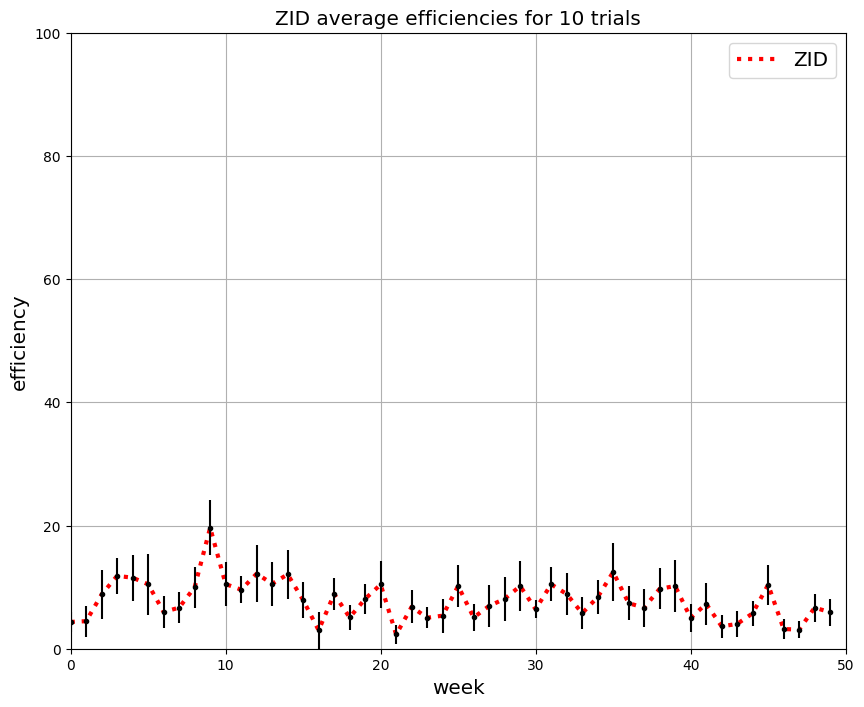

In [ ]:
import matplotlib.pyplot as plt

# TODO: Extract to helper function
x = range(num_weeks)
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(x, eff_avg, label = 'ZID', linestyle = 'dotted', color='red', lw =3)
ax.errorbar(x, eff_avg, yerr=std_error, fmt='.k')

ax.set_xlabel('week', size = 'x-large') 
ax.set_xbound(0, num_weeks)
ax.set_ybound(0, 100)
ax.grid(1)
ax.set_ylabel('efficiency', size = 'x-large') 
ax.set_title(f'ZID average efficiencies for {num_trials} trials', size = 'x-large')
ax.legend(fontsize='x-large')
plt.show()


#### Contrasting Trader Types
The ZID traders do not appear to improve in the above simulation, nor should we expect them to, as they employ no logic in their strategy and simply behave randomly. The ZIDA traders, however, can employ a simple rule-of-thumb which leads them to stay at locations where they are succeeding at making exchanges, while leaving others.

Below we demonstrate an identical simulation to above, but changing the traders out for ZIDA traders and giving them a "WINDOW" rule with a minimum of 1 trade per 7 periods (the same number of periods as 1 week above).

Note the definition of strategy parameters - these are used by the agent to help define their strategy. If you need to see the potential strategies or the potential strategy parameters, invoke the helper in dm_utils:
```
dm_utils.agent_strategy_helper() # Prints agent class (strategy) names
dm_utils.agent_strategy_helper(agent_class_name) # Prints potential strategy parameters for an agent class
```


In [5]:
dm_utils.agent_strategy_helper()

Agent Classes Available
['ZID', 'ZIDA', 'ZIDP', 'ZIDPA', 'ZIDPR', 'ZIDT', 'ZIDTR']


In [6]:
dm_utils.agent_strategy_helper('ZIDA')

ZIDA takes "reset_flag_frequency", representing the rule on which to resume movement, as a parameter. Additional parameters may be required, as specified below.
"reset_flag_frequency" can take the values of ["NONE", "START", "WEEK", "MIN_AGENTS", "WINDOW"]
NONE: Never resume movement after trading. No additional parameters
START: Resume movement at the start of each week (every time agent.start is called). No additional parameters.
WEEK: Resume movement is did not trade at least "reset_flag_min_trades" in the past week (time between agent.start is called).
MIN_AGENTS: Resume movement is there are less than "reset_flag_min_agents" agents at the same location as this agent.
WINDOW: Resume movement is did not trade at least "reset_flag_min_trades" in the last "reset_flag_window" periods.


[['BUYER_0_ZIDA', 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, (9, 10)], ['BUYER_1_ZIDA', 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, (13, 0)], ['BUYER_2_ZIDA', 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, (6, 0)], ['BUYER_3_ZIDA', 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, (3, 2)], ['BUYER_4_ZIDA', 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, 'utility', 0, (0, 12)], ['SELLER_5_ZIDA', 'SELLER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 50, 0, 'profit', 0, (9, 14)], ['SELLER_6_ZIDA',

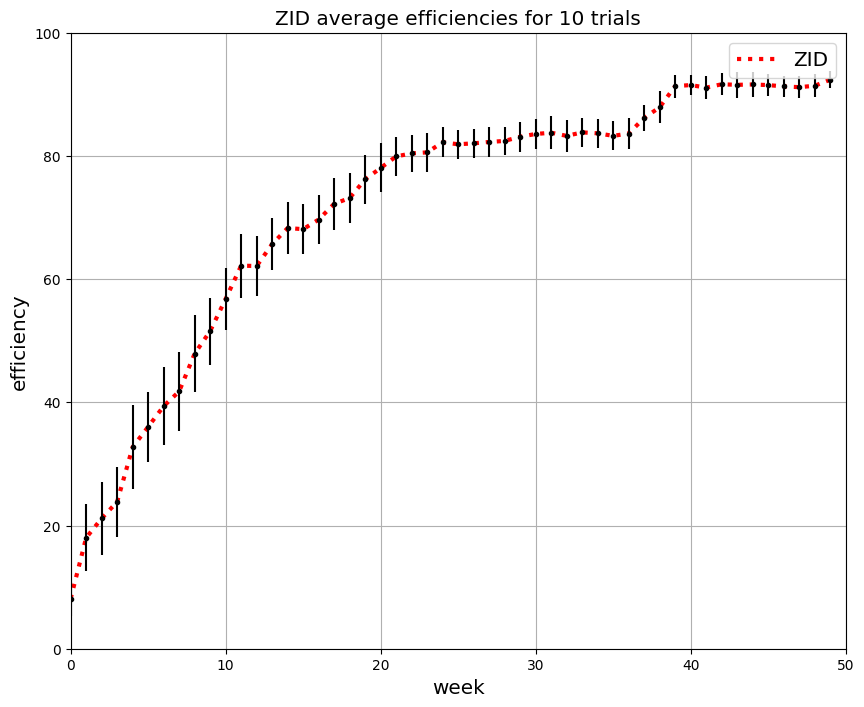

In [ ]:
sim_name = "ZIDA MONTE-CARLO" # Name your simulation
num_trials = 10 # Choose the number of trials
num_weeks = 50 # Choose the number of weeks
num_periods = 7 # Choose the number of periods in week
num_rounds = 5 # Choose the number of trading rounds within a period
grid_size = 15 # Choose the grid size
num_traders = 10 # Define the number of traders - used as a verification to check agent group definition

# Define trader groups - These are the traders which will go into your simulation
group_size = int(num_traders/2) # Note: The group size (number of agents in a group) must be an integer
lower_bound = 200 # Lower bound on 
upper_bound = 600
num_units = 8 # Number of units each trader demands/supplies
# starting endowments
buy_endow = 500
sell_endow = 0
move_error_rate = 0 # chance to randomly move and override movement strategy
starting_location = None # Location each agent starts at; None = randomly on grid
agent_class = 'ZIDA' # String name of the agent class - this class requires parameters

# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   } # Parameters required for the strategy - ZIDA and ZIDT types require inputs

buy_group = [group_size, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

sell_group = [group_size, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_weeks, sell_endow, 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

# run Monte_Carlo
data_table = sim_utils.make_monte_carlo(sim_name, 
                                        num_trials, num_periods, num_weeks, num_rounds,
                                        num_traders, agent_groups, grid_size)

eff_avg, std_error, eff_min, eff_max = sim_utils.analyze_eff_data(num_trials, num_weeks, data_table)
x = range(num_weeks)
fig, ax = plt.subplots(figsize=(10, 8))

# TODO: Replace with helper function
ax.plot(x, eff_avg, label = 'ZID', linestyle = 'dotted', color='red', lw =3)
ax.errorbar(x, eff_avg, yerr=std_error, fmt='.k')

ax.set_xlabel('week', size = 'x-large') 
ax.set_xbound(0, num_weeks)
ax.set_ybound(0, 100)
ax.grid(1)
ax.set_ylabel('efficiency', size = 'x-large') 
ax.set_title(f'ZID average efficiencies for {num_trials} trials', size = 'x-large')
ax.legend(fontsize='x-large')
plt.show()


## Coding Problem

In subsection 2.1 the simulation set a large number of control variables.  One of these sets of variables defines the agent groups. Note that the group of buyers and sellers is defined separately to allow for greater flexibility, though you can look into the env_make_agents.gen_default_agents(*) function for some simplified options.

The agent group definitions.
```
trader_objects =[(ZIDA, 6),(ZIDPA, 6), (ZID, 8)]
```
This is used when agents are initialized.  The `trader_objects` list consist of two tuples.  For example, the second tuple is,
```
(ZIDPA, 6),
```
where the first element, `ZIDPA` is the class name for the strategy being used and the second element, `6`, is the number of agent/traders that will use that strategy.  Note when we add up the numbers in each tuple they should sum to the number in `num_traders` in this case 20.

It is typical in running simulations to compare the effect of changing a control variable and then see what happens to a statistic like efficiency.  In this problem let our treatment changes be given by the list treatments as shown in the code cell below.  Your job is write a program to walk through each treatment and run a Monte_Carlo simulation for the control variables shown.  Your efficiency measures should be collected in a corresponding list so you can then plot all the measures together.  

In [8]:
ZID = dm_agents.ZID
ZIDA = dm_agents.ZIDA

# trader_objects =[] # use treatment conditions below
sim_name = "ZID and ZIDA combined MONTE-CARLO"
num_trials = 10
num_periods = 7
num_weeks = 50
num_rounds = 5
grid_size = 15
num_traders = 20
num_units = 8
lower_bound = 200 
upper_bound = 600

treatments = [ [(ZIDA, 20), (ZID,  0)], 
               [(ZIDA, 16), (ZID,  4)],
               [(ZIDA, 12), (ZID,  8)],
               [(ZIDA,  8), (ZID, 12)],
               [(ZIDA,  4), (ZID, 16)],
               [(ZIDA,  0), (ZID, 20)] ]
              

> Hint:  
* If you organize your data structures correctly you may be able to use something like the following example code to plot your results.  Note the data is totally fake and didn't use the Monte_Carlo simulation, but your code should.

In [9]:
treatments = [[(ZIDA, 20), (ZID,  0)], 
               [(ZIDA, 16), (ZID,  4)], ]

num_weeks = 8
eff_avgs = []
eff_avgs.append([10, 20, 30, 40, 50, 60, 70, 80])
eff_avgs.append([10, 17, 25, 33, 40, 48, 54, 65])
std_errors = []
std_errors.append([4, 3, 3, 2, 2, 3, 1, 1])
std_errors.append([5, 4, 4, 3, 3, 2, 2, 1])

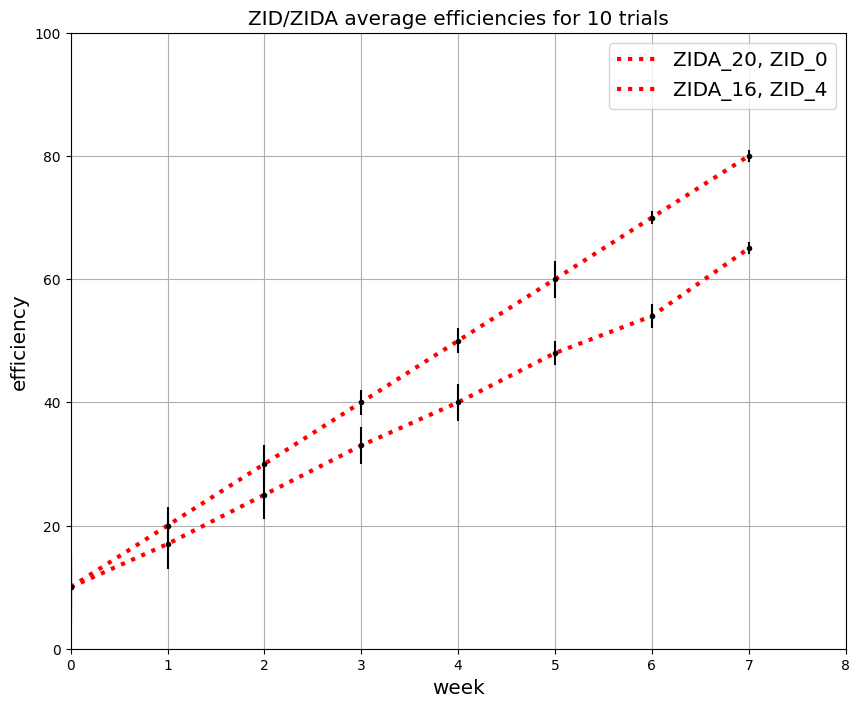

In [10]:
import matplotlib.pyplot as plt

x = range(num_weeks)
fig, ax = plt.subplots(figsize=(10, 8))

for k, treat in enumerate(treatments):
    label_txt = f"ZIDA_{treat[0][1]}, ZID_{treat[1][1]}"
    ax.plot(x, eff_avgs[k], label = label_txt, linestyle = 'dotted', color='red', lw =3)
    ax.errorbar(x, eff_avgs[k], yerr=std_errors[k], fmt='.k')

ax.set_xlabel('week', size = 'x-large') 
ax.set_xbound(0, num_weeks)
ax.set_ybound(0, 100)
ax.grid(1)
ax.set_ylabel('efficiency', size = 'x-large') 
ax.set_title(f'ZID/ZIDA average efficiencies for {num_trials} trials', size = 'x-large')
ax.legend(fontsize='x-large')

plt.show()


# Agents 

## Buyer Model

Agents are a model of the decision makers in our experiment.  In this simulation we have divided agents into an equal number of buyers and sellers.  Our mathematical model of buyers is as follows:

> **Buyers** (indexed by b) 
* reservation values: $v^b = (v_1, v_2, ..., v_K), m^b$.
    *note reservation values are decreasing or $i\le j$ implies $v_i \ge v_j$.  
* quantity bought: $q^b$
* prices paid: $p^b = (p_1, ..., p_{q^b})$
* utility:
$$u^b(q^b,p^b) = m^b + \sum_{i=1}^{q^b} v^b_i - \sum_{i = 1}^{q^b} p^b_i$$
* starting position: $e^b = (v^b, m^b, u^b, loc^b)$

So some buyer, b, has values given by $v^b = (v_1, v_2, ..., v_K)$.  Before we go any further we can ask how can we generate these values on the computer.  This is done in the `env_make_agents.py` code.  When you look at it you will see a method `gen_res_values` in the `MakeAgents` class. This method uses code similar to the code shown below.  

## Reservation value code

In [11]:
import numpy as np

num_units = 8
ub = 600
lb = 0
interval = int((ub-lb)/4)
print('interval = ',interval)
high = ub + 1
low = lb 

values = []
for unit in range(num_units):
    value = np.random.randint(low, high)
    values.append(value)
res_values = sorted(values, reverse=True)
print(f"values = {values}")
print(f"reservation values = {res_values}")


interval =  150
values = [575, 70, 475, 324, 419, 478, 408, 556]
reservation values = [575, 556, 478, 475, 419, 408, 324, 70]


> Note: You can use other generators like this one

In [12]:
import numpy as np

num_units = 8
ub = 600
lb = 0
high = ub + 1
low = lb 

values = []
for unit in range(num_units):
    value = np.random.randint(low, high)
    values.append(value)
    low = lb = int(value/2)
    high = value + 1
res_values = sorted(values, reverse=True)
print(f"values = {values}")
print(f"reservation values = {res_values}")


values = [595, 431, 282, 149, 143, 135, 85, 84]
reservation values = [595, 431, 282, 149, 143, 135, 85, 84]


Notice how this works.  
* Line 1 imports numpy
* Lines 3-8 set up to use numpy's function `random.randint(low, high)` which returns a random integer in the range low to high - 1.
* line 10 defines a list to hold values.
* lines 11-13 defines the values and puts them in the list
The list `values` is printed out to show you their random nature.  To turn these values into reservation values we have to sort them from highest to lowest using the builtin Python function `sorted` shown on line 14.   


## Plotting individual demand curves

In [13]:
def plot_ind_demand(res_values, price):
    """Plot individual demand"""
    
    dunits = [units for units in range(len(res_values) + 2)] 
    munits = len(dunits)
    max_value = res_values[0]   
    demand_values = [max_value] # sets up first step
    demand_values.extend(res_values)
    demand_values.append(0) # brings curve back down to zero

    """
    Set up plot
    """
    plt.figure(figsize=(10, 7.5))  # Set plot dimensions
    ax = plt.subplot(111)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)

    """
    Made a bunch of small changes here
    """
    plt.step(dunits, demand_values, label='Demand')
    plt.axhline(y=price, xmin=0, xmax=8, color='r', linestyle='-', linewidth=3)
    ax.annotate('PRICE', xy=(5,price), xytext=(0,5), textcoords='offset points')

    ax = plt.gca()
    plt.legend(loc='upper center', frameon=False)
    plt.title('Individual Demand')
    plt.xlabel('units')
    plt.ylabel('currrency')

    """
    Try annotating
    """
    #for i, v in enumerate(demand_values):
    #    ax.text(i, v+5, "%d" %v, ha="center")

    for i, v in enumerate(demand_values[1:-1]):
        ax.annotate(str(v), xy=(i,v), xytext=(20,5), textcoords='offset points')
        # this works but (20, 5) is hardcoded in a not nice way

    plt.xlim(0, munits)
    plt.ylim(0, max(demand_values))
    plt.show()


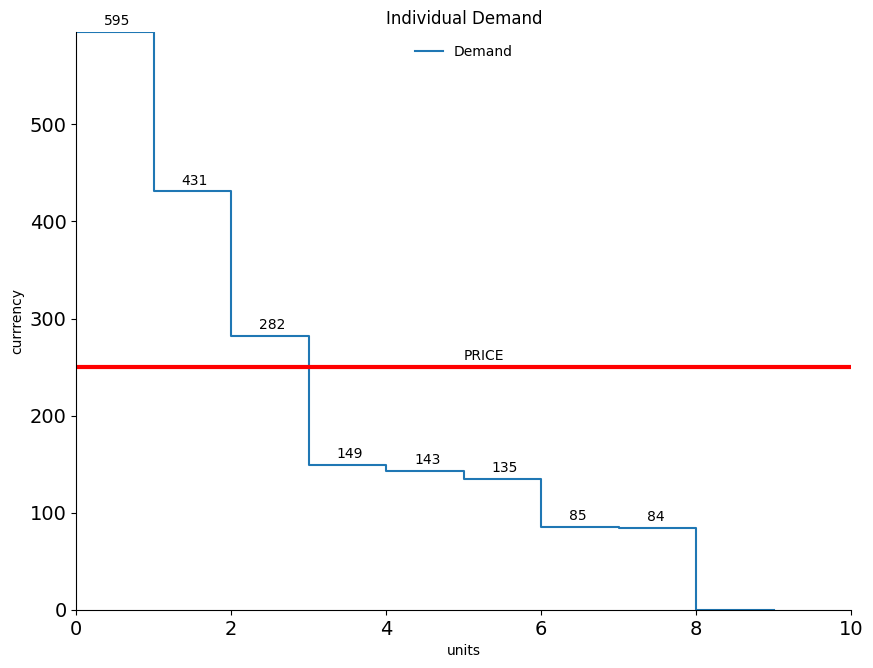

At price 250 our individual will buy 3 units and produce 558 surplus.


In [14]:
price = 250
plot_ind_demand(res_values, price)
q_units = 0
surp = 0
for val in res_values:
    if val >= price:
        q_units += 1
        surp += val-price
print (f"At price {price} our individual will buy {q_units} units \
and produce {surp} surplus.")

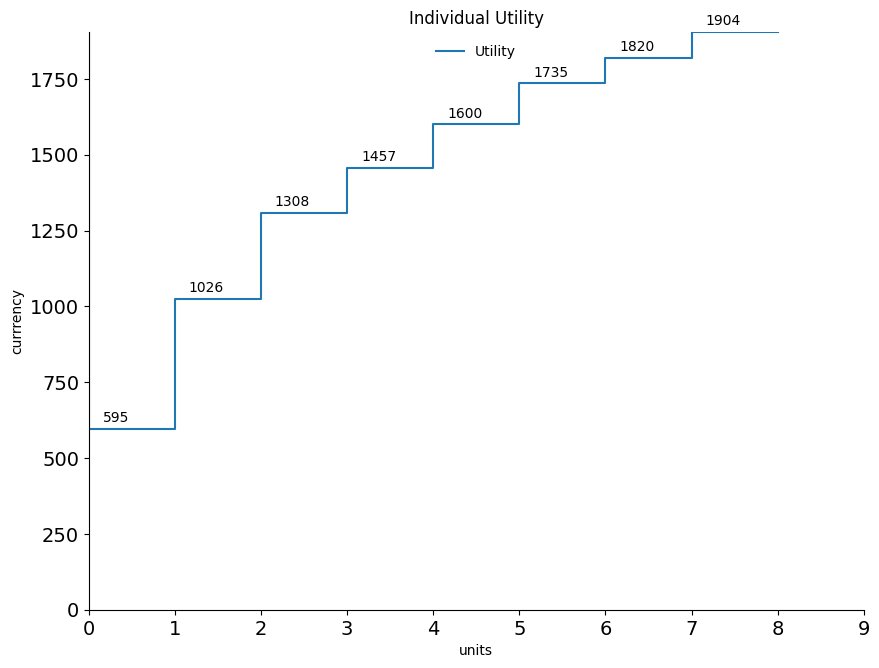

In [15]:
dunits = [units for units in range(len(res_values) + 1)] 
utility = []
util = 0
for k, val in enumerate(res_values):
    utility.append(util + val)
    util += val
munits = len(dunits)
max_value = util   
utility_values = [max_value] # sets up first step
utility_values.extend(utility)
# demand_values.append(0) # brings curve back down to zero

"""
Set up plot
"""
plt.figure(figsize=(10, 7.5))  # Set plot dimensions
ax = plt.subplot(111)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

"""
Made a bunch of small changes here
"""
plt.step(dunits, utility_values, label='Utility')

ax = plt.gca()
plt.legend(loc='upper center', frameon=False)
plt.title('Individual Utility')
plt.xlabel('units')
plt.ylabel('currrency')

"""
Try annotating
"""
#for i, v in enumerate(demand_values):
#    ax.text(i, v+5, "%d" %v, ha="center")

for i, v in enumerate(utility_values[1:]):
    ax.annotate(str(v), xy=(i,v), xytext=(10,5), textcoords='offset points')
    # this works but (30, 5) is hardcoded in a not nice way
    
plt.xlim(0, munits)
plt.ylim(0, max(utility_values))
plt.show()


## Seller Model

> **Sellers** (indexed by s) 
* unit costs: $c^s = (c_1, c_2, ..., c_K), m^s$.
    * note unit costs are increasing or $i\ge j$ implies $c_i \ge c_j$.
* quantity sold: $q^s$
* prices received: $p^s = (p_1, ..., p_{q^s})$
* profit:
$$\pi^s(q^s,p^s) = m^s + \sum_{i=1}^{q^s} p^s_i - \sum_{i = 1}^{q^s} c^s_i$$
* starting position: $e^s = (c^s, m^s, \pi^s, loc^s)$

In [16]:
from scipy.stats import sem
names = ['ZID', 'ZIDA']
trader_objects =  [['ZID', 10], ['ZIDA', 10]]

week_sur = {}
type_avg = {}

for name in names:
    week_sur[name] = []
    type_avg[name] = []
    
for week in range(num_weeks):
    for name in names:
        type_avg[name].append(0)
        week_sur[name].append([])

for trial in range(num_trials):
    effs = []
    trial_surplus = []
    trial_data = data_table[trial]
    
    for week in range(num_weeks):
        week_data = trial_data[week]
        effs.append(week_data['eff'])
        trial_surplus.append(week_data['type_effs'])
    
    for week in range(num_weeks):
        surplus = trial_surplus[week]
        for j, name in enumerate(names):
            num_players = trader_objects[j][1]
            if name in surplus:
                sur = surplus[name]
                sur/=num_players
                week_sur[name][week].append(sur)
                type_avg[name][week] += sur
            else:
                sur = 0
                week_sur[name][week].append(sur)
                type_avg[name][week] += sur

# Calculate avg and sem for each week

std_errors = {}
for name in names:
    std_errors[name] = []    
    for k in range(num_weeks):
        type_avg[name][k] /= (num_trials)
        std_error = sem(week_sur[name][k])
        std_errors[name].append(std_error)

[78.92, 104.33999999999999, 77.27000000000001, 29.95, 21.830000000000002, 67.26, 39.730000000000004, 75.36999999999999]
[np.float64(31.11182626162169), np.float64(37.26810432528062), np.float64(25.639518326208858), np.float64(16.07011892371124), np.float64(14.554938451719176), np.float64(24.56006333687092), np.float64(20.90136651566644), np.float64(26.779702305207863)]


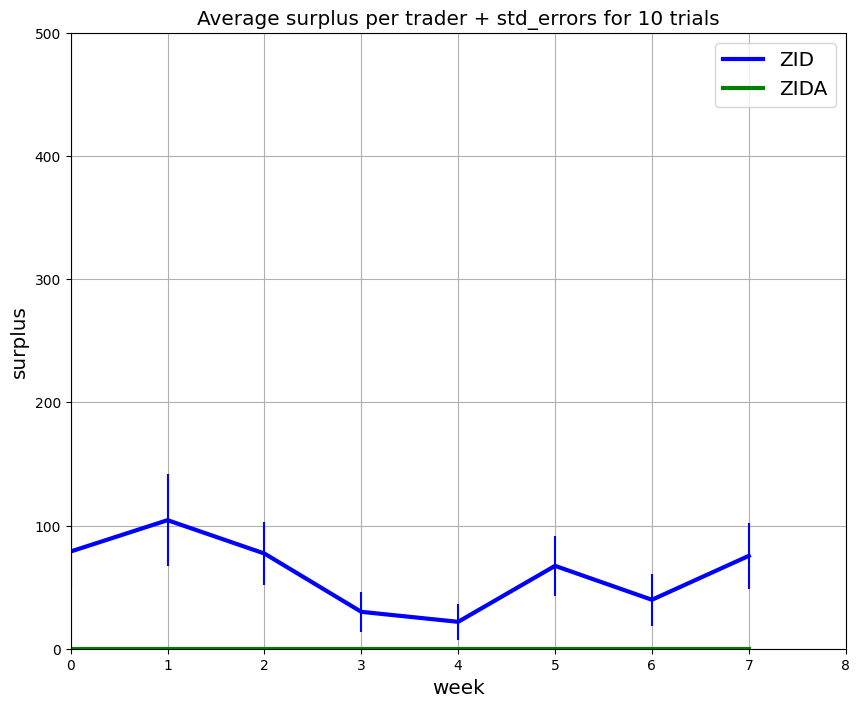

In [17]:
x = [k for k in range(num_weeks)]
fig, ax = plt.subplots(figsize=(10, 8))
print(type_avg['ZID'])
print(std_errors['ZID'])
ax.plot(type_avg['ZID'], label = 'ZID', linestyle = 'solid', color='blue', lw =3)
ax.errorbar(x, type_avg['ZID'], yerr=std_errors['ZID'], color='blue')

ax.plot(type_avg['ZIDA'], label = 'ZIDA', linestyle = 'solid', color='green', lw =3)
ax.errorbar(x, type_avg['ZIDA'], yerr=std_errors['ZIDA'], color = 'green')

ax.set_xlabel('week', size = 'x-large') 
ax.set_xbound(0, num_weeks)
ax.set_ybound(0, 500)
ax.grid(1)
ax.set_ylabel('surplus', size = 'x-large') 
ax.set_title(f'Average surplus per trader + std_errors for {num_trials} trials', size = 'x-large')
ax.legend(fontsize='x-large')
plt.show()

In [18]:
# show data_structure for data_table
show_data_struct = False
if show_data_struct:
    print(trial, 'parms', data_table['parms'])
    for trial in range(num_trials):
        print(f"trial = {trial}")
        trial_data = data_table[trial]
        for week in range(num_weeks):
            print(f"week = {week}")
            week_data = trial_data[week]
            print(trial, week, 'contracts', week_data['contracts'])
            print()
            print(trial, week, 'grids', week_data['grids'])
            print()
            print(trial, week, 'eff', week_data['eff'])
            print()
            print(trial, week, 'type_effs') 
            for key in week_data['type_effs']:
                print(key, week_data['type_effs'][key])
            print() 


If you were able to execute the above cells without issue, you should be set up correctly and can proceed deeper into the user guide.

## Program Flow

![Program Flow](../assets/program_flow.jpg)

> Travel rules for movement along torus  
> But note our grid is a bounded square (not torus)
```
if loc[0] + x_dir < 0:
    location_x = loc[0] + x_dir + self.grid_dimension
elif loc[0] + x_dir > self.grid_dimension -1:
    location_x = loc[0] + x_dir - self.grid_dimension
else:
    location_x = loc[0]+ x_dir
if loc[1] + y_dir < 0:
    location_y = loc[1] + y_dir + self.grid_dimension
elif loc[1] + y_dir > self.grid_dimension -1:
    location_y = loc[1] + y_dir - self.grid_dimension

loc = (location_x, location_y)
```

# Technical Notes

##TODO InDev